In [1]:
import networkx as nx
import csv
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from graph import Graph

In [2]:
all_files = {}

all_files['nodes_all'] = "2025_Problem_D_Data/nodes_all.csv"
all_files['edges_all'] = "2025_Problem_D_Data/edges_all.csv"
all_files['nodes_drive'] = "2025_Problem_D_Data/nodes_drive.csv"
all_files['edges_drive'] = "2025_Problem_D_Data/edges_drive.csv"
all_files['Bus_Stops'] = "2025_Problem_D_Data/Bus_Stops.csv"
all_files['SHA'] = "2025_Problem_D_Data/MDOT_SHA_Annual_Average_Daily_Traffic_Baltimore.csv"
all_files['Cache'] = "saved_graphs/network_graph.pkl"

In [3]:
G = Graph(all_files['nodes_all'], all_files['edges_all'], all_files['Bus_Stops'], all_files['Cache'])

Graph loaded from saved_graphs/network_graph.pkl


In [4]:
label_years = []
data = {}

data['Fort McHenry'] = []
data['Harbor Tunnel'] = []

with open (all_files['SHA'], 'r') as f:
    reader = csv.DictReader(f)
    
    for row in reader:
        if row['Road Name'] == 'FORT MCHENRY TUNNEL':
            sample = []
            for key in row:
                if key.startswith("AADT"):
                    if key[5].isdigit() or key == 'AADT (Current)':
                        if row[key].strip():
                            sample.append(float(row[key]))
                            if key not in label_years:
                                label_years.append(key)
            data['Fort McHenry'].append(sample)
        elif row['Road Name'] == 'HARBOR TUNNEL THRUWAY':
            sample = []
            for key in row:
                if key.startswith("AADT"):
                    if key[5].isdigit() or key == 'AADT (Current)':
                        if row[key].strip():
                            sample.append(float(row[key]))
            data['Harbor Tunnel'].append(sample)

In [5]:
for sample in data['Fort McHenry']:
    print(sample)

[104182.0, 104450.0, 106644.0, 109205.0, 108555.0, 103175.0, 109325.0, 88015.0, 99555.0, 100455.0]
[123915.0, 125725.0, 128375.0, 131465.0, 130685.0, 138824.0, 147130.0, 118441.0, 133962.0, 135173.0]
[104182.0, 104450.0, 106644.0, 109205.0, 108555.0, 103175.0, 109325.0, 88015.0, 99555.0, 100455.0]
[127255.0, 130075.0, 132815.0, 136005.0, 135195.0, 138044.0, 146310.0, 117781.0, 133212.0, 134413.0]
[167725.0, 174325.0, 177995.0, 182275.0, 181185.0, 172165.0, 182455.0, 146885.0, 166135.0, 167635.0]
[114386.0, 115615.0, 122820.0, 124391.0, 125930.0, 121275.0, 140185.0, 112510.0, 119887.0, 118287.0]
[167675.0, 174200.0, 177865.0, 182135.0, 181045.0, 182984.0, 193950.0, 156131.0, 176582.0, 178173.0]


In [6]:
import numpy as np

# Convert the list of lists into a numpy array for easier manipulation
fort_mchenry_data = np.array(data['Fort McHenry'])

# Calculate the mean for each column (year)
average_aadt_fort_mchenry = np.mean(fort_mchenry_data, axis=0)

# Print the average AADT for each year
for year, avg in zip(label_years, average_aadt_fort_mchenry):
    print(f"{year}: {avg}")

AADT 2014: 129902.85714285714
AADT 2015: 132691.42857142858
AADT 2016: 136165.42857142858
AADT 2017: 139240.14285714287
AADT 2018: 138735.7142857143
AADT (Current): 137091.7142857143
AADT 2019: 146954.2857142857
AADT 2020: 118254.0
AADT 2021: 132698.2857142857
AADT 2022: 133513.0


In [7]:
for sample in data['Harbor Tunnel']:
    print(sample)

[61413.0, 70425.0, 71901.0, 73632.0, 73193.0, 82570.0, 46044.0, 37075.0, 41935.0, 42315.0]
[16373.0, 24050.0, 24561.0, 25152.0, 25003.0, 15422.0, 15734.0, 12675.0, 14880.0, 15011.0]
[11433.0, 13940.0, 14211.0, 14552.0, 14423.0, 13750.0, 14424.0, 12045.0, 13785.0, 13875.0]
[13273.0, 16800.0, 17121.0, 17532.0, 17373.0, 7013.0, 10934.0, 6000.0, 6861.0, 6902.0]
[32663.0, 46475.0, 47451.0, 48592.0, 48303.0, 28685.0, 30384.0, 24465.0, 27675.0, 27925.0]
[63853.0, 80000.0, 81681.0, 83642.0, 83143.0, 70633.0, 52294.0, 34250.0, 38741.0, 68771.0]
[60523.0, 69850.0, 71321.0, 73032.0, 72593.0, 64850.0, 45664.0, 36765.0, 41585.0, 41965.0]
[57303.0, 69850.0, 71321.0, 73032.0, 61570.0, 65340.0, 38731.0, 31182.0, 35273.0, 35594.0]
[63613.0, 73975.0, 75531.0, 77342.0, 77030.0, 66500.0, 48451.0, 39002.0, 44113.0, 44514.0]
[50803.0, 54050.0, 55191.0, 56522.0, 56183.0, 68680.0, 35344.0, 28455.0, 32185.0, 32485.0]
[65553.0, 82550.0, 84281.0, 86302.0, 85783.0, 73590.0, 53954.0, 43435.0, 49135.0, 49585.0]
[61

In [8]:
import numpy as np

# Convert the list of lists into a numpy array for easier manipulation
harbor_tunnel_data = np.array(data['Harbor Tunnel'])

# Calculate the mean for each column (year)
average_aadt_harbor_tunnel = np.mean(harbor_tunnel_data, axis=0)

# Print the average AADT for each year
for year, avg in zip(label_years, average_aadt_harbor_tunnel):
    print(f"{year}: {avg}")

AADT 2014: 49283.142857142855
AADT 2015: 57965.857142857145
AADT 2016: 59063.71428571428
AADT 2017: 60391.642857142855
AADT 2018: 59114.5
AADT (Current): 55782.642857142855
AADT 2019: 39304.78571428572
AADT 2020: 31008.0
AADT 2021: 36854.21428571428
AADT 2022: 39844.642857142855


In [9]:
true_labels_fort_mchenry = []
true_labels_harbor_tunnel = []

In [10]:
test_forc = []
test_harb = []

for i in range(len(label_years)):
    if label_years[i] == 'AADT (Current)':
        true_labels_fort_mchenry.append(average_aadt_fort_mchenry[i])
        true_labels_harbor_tunnel.append(average_aadt_harbor_tunnel[i])
    
    test_forc.append(average_aadt_fort_mchenry[i])
    test_harb.append(average_aadt_harbor_tunnel[i])

In [11]:
print(true_labels_fort_mchenry)
print(true_labels_harbor_tunnel)

[np.float64(137091.7142857143)]
[np.float64(55782.642857142855)]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


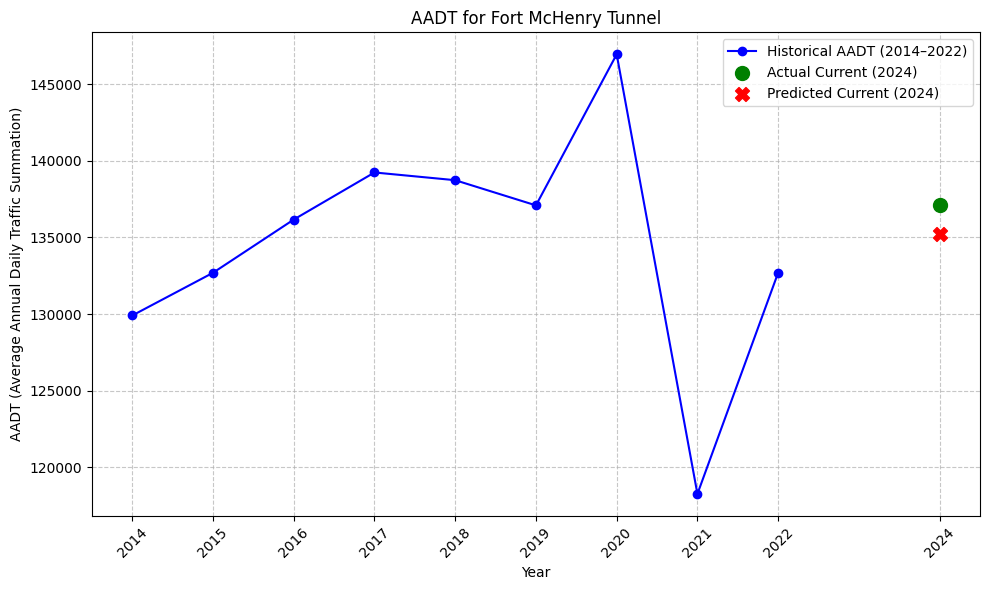

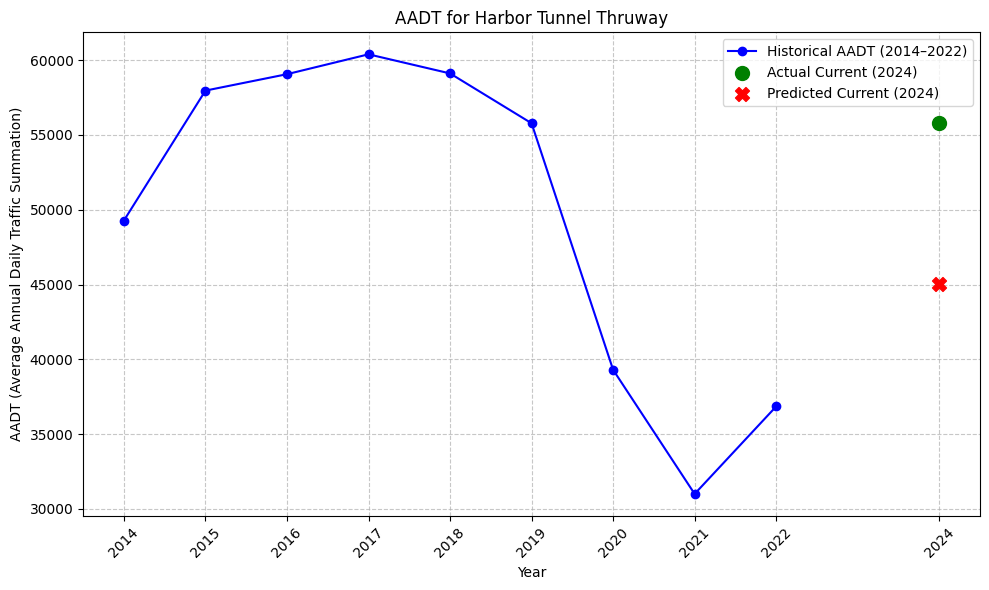

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from keras.models import load_model
from keras.preprocessing.sequence import pad_sequences

# Load the saved model
model = load_model('models/aadt_predictor.keras')  # Update path if needed

# Define years (2014 to 2022 + current year)
historical_years = list(range(2014, 2023))  # 2014–2022
current_year = 2024  # Assuming current year is 2023

# Preprocess and predict
def preprocess_and_predict(data, max_length):
    # Extract historical data (exclude last element, which is the actual current value)
    historical = data[:-1]
    # Pad to match model's expected input shape
    padded = pad_sequences([historical], maxlen=max_length, padding='post', dtype='float32')
    return padded.reshape(1, max_length, 1)

# Get max_length from model input shape
max_length = model.input_shape[1]

# Process test_forc
test_forc_historical = test_forc[:-1]
test_forc_actual = true_labels_fort_mchenry
test_forc_processed = preprocess_and_predict(test_forc, max_length)
test_forc_pred = model.predict(test_forc_processed)[0][0]

# Process test_harb
test_harb_historical = test_harb[:-1]
test_harb_actual = true_labels_harbor_tunnel
test_harb_processed = preprocess_and_predict(test_harb, max_length)
test_harb_pred = model.predict(test_harb_processed)[0][0]

# Plotting function
def plot_aadt(tunnel_name, historical_years, historical_aadt, actual_current, predicted_current, current_year):
    plt.figure(figsize=(10, 6))
    
    # Plot historical data
    plt.plot(
        historical_years, historical_aadt, 
        marker='o', linestyle='-', color='blue', 
        label='Historical AADT (2014–2022)'
    )
    
    # Plot current year actual and predicted
    plt.scatter(
        current_year, actual_current, 
        marker='o', color='green', s=100, 
        label='Actual Current (2024)', zorder=5
    )
    plt.scatter(
        current_year, predicted_current, 
        marker='X', color='red', s=100, 
        label='Predicted Current (2024)', zorder=5
    )
    
    plt.title(f'AADT for {tunnel_name}')
    plt.xlabel('Year')
    plt.ylabel('AADT (Average Annual Daily Traffic Summation)')
    plt.xticks(historical_years + [current_year], rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Generate plots
plot_aadt(
    tunnel_name="Fort McHenry Tunnel",
    historical_years=historical_years,
    historical_aadt=test_forc_historical,
    actual_current=test_forc_actual,
    predicted_current=test_forc_pred,
    current_year=current_year
)

plot_aadt(
    tunnel_name="Harbor Tunnel Thruway",
    historical_years=historical_years,
    historical_aadt=test_harb_historical,
    actual_current=test_harb_actual,
    predicted_current=test_harb_pred,
    current_year=current_year
)